In [2]:
pip install Pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance


#keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle


### Load dataset:

In [14]:
train_dir = 'dataset\Training'
test_dir = 'dataset\Testing'

train_paths = []
train_labels = []


for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)


# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

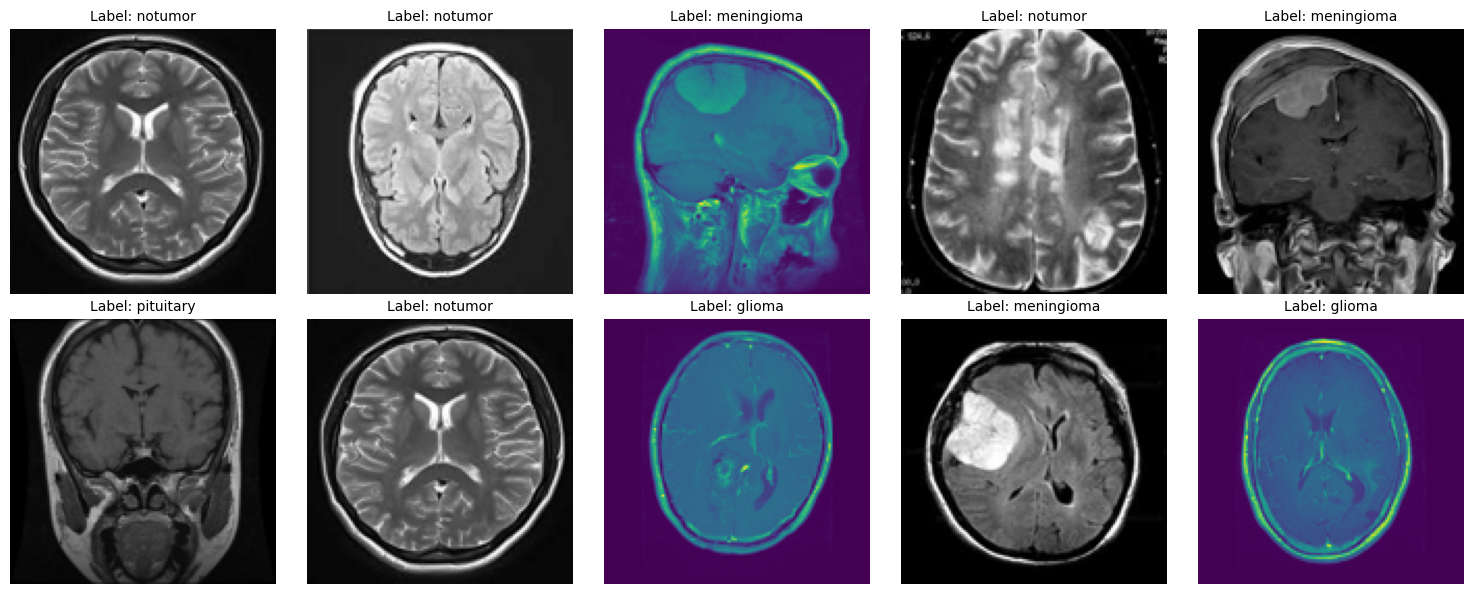

In [8]:
import random
import matplotlib.pyplot as plt

#select random indices for 10 images:
random_indices = random.sample(range(len(train_paths)), 10)

#create a figure to display images in 2 rows
fig, axes = plt.subplots(2,5, figsize=(15, 6))
axes = axes.ravel()  #1d mein krne ke liye

#loop through the random indices and display images
for i, idx in enumerate(random_indices):
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((128, 128))

    #display images
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()

## Image preprocessing 

In [9]:
def augument_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image)/255.0
    return image

#load image and apply augumentation:
def open_images(paths):
    images = []
    for path in paths:
        img = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        img = augument_image(img)
        images.append(img)
    return np.array(images)

#encoder labels(convert label names to integers):
def encode_label(labels):
    unique_labels = os.listdir(train_dir)  # Ensure unique labels are determined
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)


#data generator for batching:
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels  # Yield the batch

### model architecture (128, 128, 3)


In [11]:
IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

#top layer use ni kri, since hume bas uski pre trained knowledge chahiye exact model ni we will train our model
#weight humne image net ke liye for better result

#freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

#set only the last few layers for pre trained knowledge
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True


#build model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model) #VGG 16
model.add(Flatten()) #flatten layer (multidimensional to 1d krne ke liye)
model.add(Dropout(0.3)) #dropout layer - drop randomly 30% neuron to prevent overfitting

model.add(Dense(128, activation='relu')) #dense layer
model.add(Dropout(0.2))

#output layer - multiclass h isliye softmax
model.add(Dense(4, activation='softmax'))

#compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

#parameters:
batch_size = 20
steps = int(len(train_paths)/batch_size)
epochs = 5

#train the model:
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step
Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 222s 784ms/step - loss: 0.4797 - sparse_categorical_accuracy: 0.8191
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 428s 2s/step - loss: 0.2440 - sparse_categorical_accuracy: 0.9079
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 214s 763ms/step - loss: 0.1704 - sparse_categorical_accuracy: 0.9307
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 213s 760ms/step - loss: 0.1355 - sparse_categorical_accuracy: 0.9480
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 211s 755ms/step - loss: 0.0894 - sparse_categorical_accuracy: 0.9680


## train and val plots


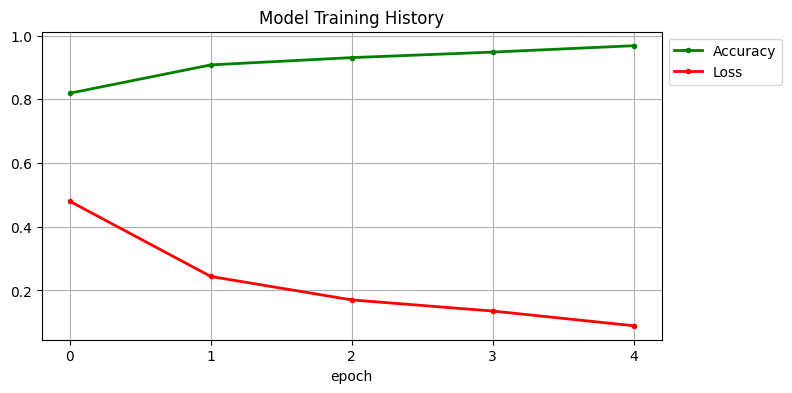

In [13]:
plt.figure(figsize = (8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

### Model classification report


In [17]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import label_binarize
import numpy as np

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.77      0.83       400
           1       0.83      0.96      0.89       400
           2       0.91      0.99      0.95       400
           3       1.00      0.90      0.95       400

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.91      0.91      0.91      1600



Confusion Matrix:
[[308  59  33   0]
 [ 12 386   2   0]
 [  0   2 398   0]
 [ 19  20   2 359]]


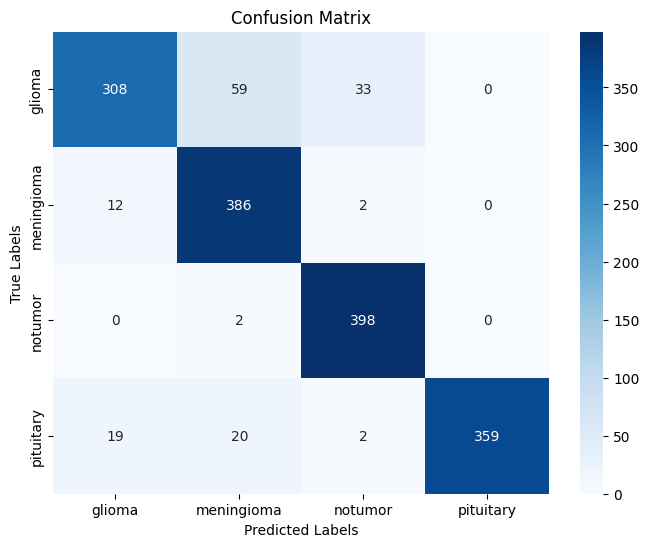

In [18]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

### ROC Curve:

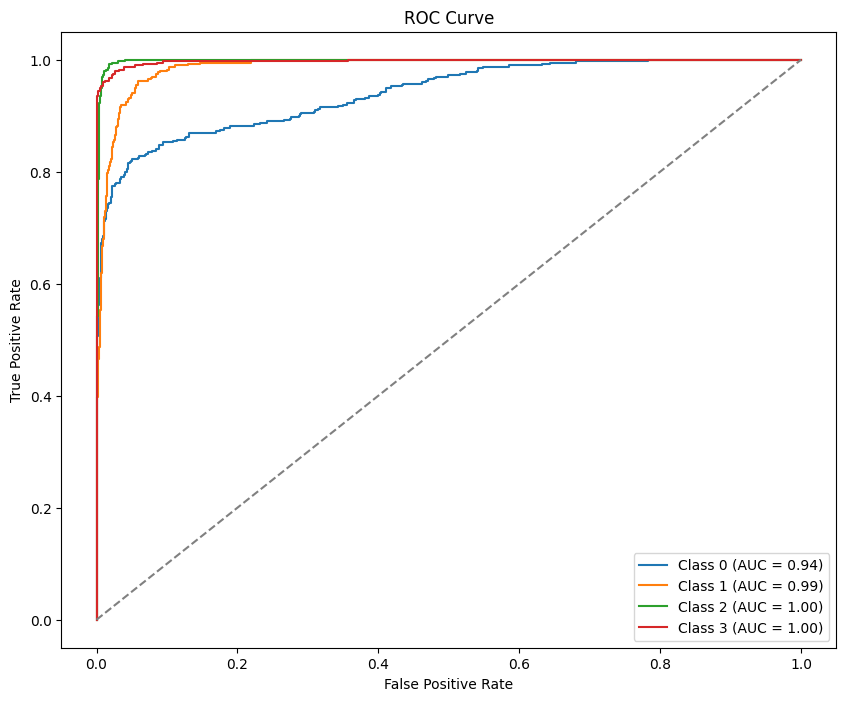

In [19]:
# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

## save the model:

In [20]:
model.save('model.h5')

In [25]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class labels
# class_labels = ['glioma', 'meningioma', 'notumor', 'pituitary']
class_labels = os.listdir(train_dir) 

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


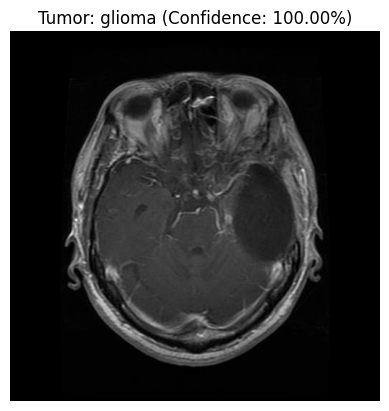

In [28]:
image_path = 'Te-gl_0015.jpg'
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


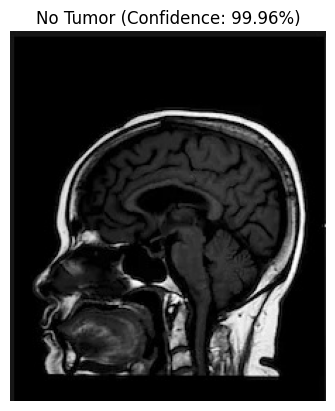

In [29]:
image_path = 'Te-noTr_0004.jpg'
detect_and_display(image_path, model)